# Number of Training Samples

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [69]:
experiment = "num_train_samples"

dataset = "aitv2"
scenario = "santos"

logic_files = [
    "ait_logic", 
    "ait_flags",
]

baseline_models = [
    "multiclass",
    "ensemble",
]

In [70]:
experiments = {}

In [71]:
for logic_file in logic_files:
    metrics_dir = Path(f"../../experiments_old/{dataset}/{experiment}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}
    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        if "pretrained" in experiment_name:
            model_name = f"dpl_{logic_file}_pretrained"
        else:
            continue
            model_name = f"dpl_{logic_file}_end_to_end"

        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()

        subset = experiment_name_parts[-3]
        subset_size = int(subset.split("b")[0])

        mf1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [72]:
for logic_file in logic_files:
    metrics_dir = Path(f"../../experiments_old/{dataset}/{experiment}/deepproblog/{logic_file}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}
    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")

        if "pretrained" in experiment_name:
            continue
            model_name = f"dpl_{logic_file}_pretrained"
        else:
            model_name = f"dpl_{logic_file}_end_to_end"

        # print(f"Processing {experiment_name}...")
        data = np.load(file_path, allow_pickle=True)
        metrics = data["metrics"].item()

        subset = experiment_name_parts[-3]
        subset_size = int(subset.split("b")[0])

        mf1_scores[subset_size] = metrics["macro_f1"]
        false_positives[subset_size] = metrics["false_alarm_rate"]
        detection_rates[subset_size] = metrics["detection_rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [73]:
for model in baseline_models:
    model_name = f"baseline_{model}"
    metrics_dir = Path(f"../../experiments_old/{dataset}/{experiment}/baselines/{model}/metrics")
    file_paths = list(metrics_dir.iterdir())

    mf1_scores = {}
    false_positives = {}
    detection_rates = {}

    for file_path in file_paths:
        experiment_name = str(file_path.stem)
        experiment_name_parts = experiment_name.split("_")
        
        # print(f"Processing {experiment_name}...")
        with open(file_path) as f:
            metrics = json.load(f)
        
        subset = experiment_name_parts[-1]
        subset_size = int(subset.split("b")[0])
        mf1_scores[subset_size] = metrics["Macro F1"]
        false_positives[subset_size] = metrics["False Alarm Rate"]
        detection_rates[subset_size] = metrics["Detection Rate"]

    scores_zip = zip(mf1_scores.keys(), mf1_scores.values(), false_positives.values(), detection_rates.values())
    scores_sorted = sorted(scores_zip, key=lambda x: x[0])

    experiments[model_name] = {
        "subset_sizes": [item[0] for item in scores_sorted],
        "mf1_scores": [item[1] for item in scores_sorted], 
        "false_positive_rates": [item[2] for item in scores_sorted],
        "detection_rates": [item[3] for item in scores_sorted]
    }


In [74]:
experiments

{'dpl_ait_logic_pretrained': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1000,
   5000,
   10000],
  'mf1_scores': [0.8614015186456296,
   0.8603554213559088,
   0.8633598811890192,
   0.8726880892440196,
   0.883179372496836,
   0.8723502573611424,
   0.8475775911510219,
   0.854127939485382,
   0.8760534360031466,
   0.871516476482981],
  'false_positive_rates': [0.0002545253102962974,
   0.0002320671946819182,
   0.00020212304052941263,
   0.0002919555029869294,
   0.0004117321195969517,
   0.00043419023521133087,
   0.001003129164108937,
   0.0007860340465032714,
   0.00035184381129194054,
   0.0003443577727538141],
  'detection_rates': [0.9909502262443439,
   0.9908171413361725,
   0.9913494809688581,
   0.9917487356933724,
   0.9924141602342295,
   0.9926803300505722,
   0.993878094224115,
   0.9946766036731435,
   0.9930795847750865,
   0.9932126696832579]},
 'dpl_ait_flags_pretrained': {'subset_sizes': [5,
   10,
   20,
   30,
   50,
   100,
   500,
   1

In [75]:
def num_samples_plot(experiments, metric, plots_dir, plots_title, save_fig=True):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    all_subset_sizes = sorted({x for data in experiments.values() for x in data["subset_sizes"]})
    
    # Color palette
    colors = plt.cm.tab10.colors

    for i, (logic_file, data) in enumerate(experiments.items()):
        ax.plot(
            data["subset_sizes"], 
            data[metric], 
            marker='o',
            markersize=8,
            linewidth=2.5,
            color=colors[i % len(colors)],
            label=logic_file
        )
    
    ax.set_xscale('log')
    ax.set_xticks(all_subset_sizes)
    ax.set_xticklabels([f'{x:,}' for x in all_subset_sizes])
    
    ax.set_xlabel('num. of train samples', fontsize=12, fontweight='medium')
    ax.set_ylabel(metric.replace("_", " "), fontsize=12, fontweight='medium')
    ax.set_title(plots_title, fontsize=14, pad=15)
    
    ax.legend(frameon=True, fancybox=True, shadow=False, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    
    plots_dir.mkdir(parents=True, exist_ok=True)
    if save_fig:
        plt.savefig(plots_dir / f"num_train_samples_{metric}.png", dpi=150, bbox_inches='tight')
    plt.show()


In [76]:
# def num_samples_plot(
#     experiments,
#     metric,
#     plots_dir,
#     plots_title,
#     save_fig=True,
# ):

#     fig, ax = plt.subplots(figsize=(9, 5.5))

#     colors = plt.cm.Set2.colors

#     for i, (model_name, data) in enumerate(experiments.items()):

#         x = np.array(data["subset_sizes"])
#         y = np.array(data[metric])

#         # confidence interval
#         std = np.array(data[f"{metric}_std"])

#         color = colors[i % len(colors)]

#         # -------------------------
#         # confidence band
#         # -------------------------
#         ax.fill_between(
#             x,
#             y - std,
#             y + std,
#             color=color,
#             alpha=0.18
#         )

#         # -------------------------
#         # main line
#         # -------------------------
#         ax.plot(
#             x,
#             y,
#             marker='o',
#             markersize=5,
#             linewidth=2.2,
#             color=color,
#             label=model_name
#         )

#     # -------------------------
#     # x-axis
#     # -------------------------
#     ax.set_xscale("log")

#     all_subset_sizes = sorted({
#         x for d in experiments.values()
#         for x in d["subset_sizes"]
#     })

#     # fewer ticks
#     tick_positions = all_subset_sizes[::2]

#     ax.set_xticks(tick_positions)
#     ax.set_xticklabels([f"{x:,}" for x in tick_positions])

#     # -------------------------
#     # labels
#     # -------------------------
#     ax.set_xlabel("Training Samples", fontsize=12)
#     ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)

#     ax.set_title(
#         plots_title,
#         fontsize=14,
#         pad=12
#     )

#     # -------------------------
#     # clean styling
#     # -------------------------
#     ax.grid(
#         True,
#         linestyle="--",
#         linewidth=0.6,
#         alpha=0.35
#     )

#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     ax.spines["left"].set_alpha(0.3)
#     ax.spines["bottom"].set_alpha(0.3)

#     ax.tick_params(axis='both', labelsize=10)

#     # -------------------------
#     # legend
#     # -------------------------
#     ax.legend(
#         frameon=False,
#         bbox_to_anchor=(1.02, 0.5),
#         loc="center left",
#         fontsize=10
#     )

#     plt.tight_layout()

#     plots_dir.mkdir(parents=True, exist_ok=True)

#     if save_fig:
#         plt.savefig(
#             plots_dir / f"{metric}.png",
#             dpi=300,
#             bbox_inches="tight"
#         )

#     plt.show()

In [77]:
plots_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
plots_dir.mkdir(parents=True, exist_ok=True)

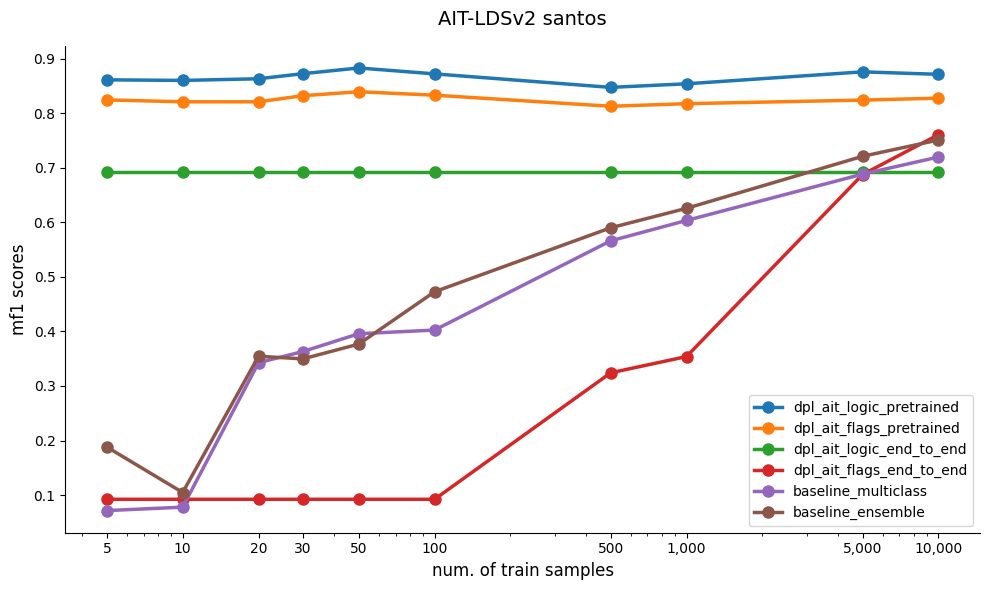

In [78]:
plots_title = f"AIT-LDSv2 santos"
metric = "mf1_scores"
num_samples_plot(experiments, metric, plots_dir, plots_title)

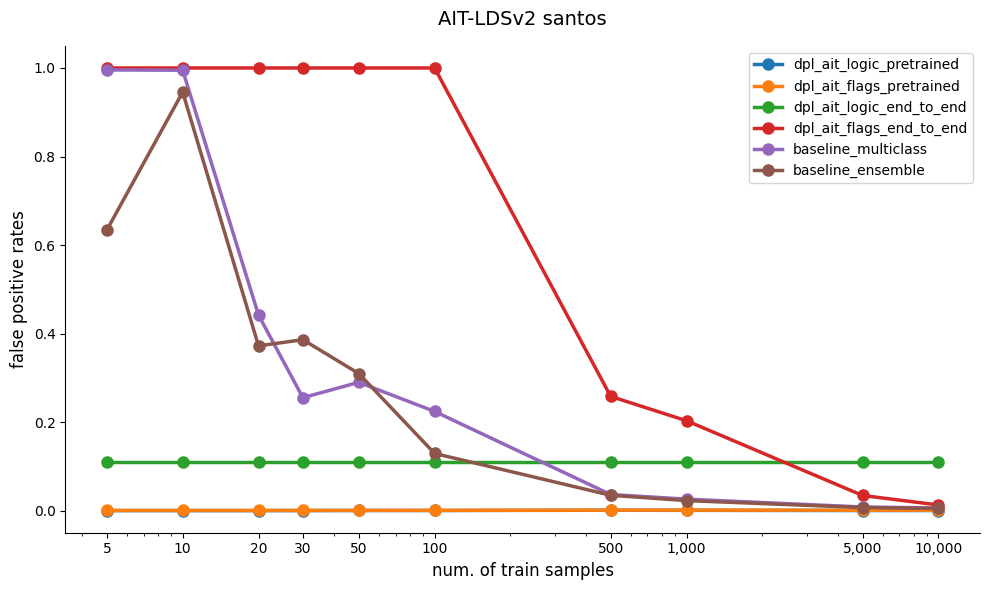

In [79]:
metric = "false_positive_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)

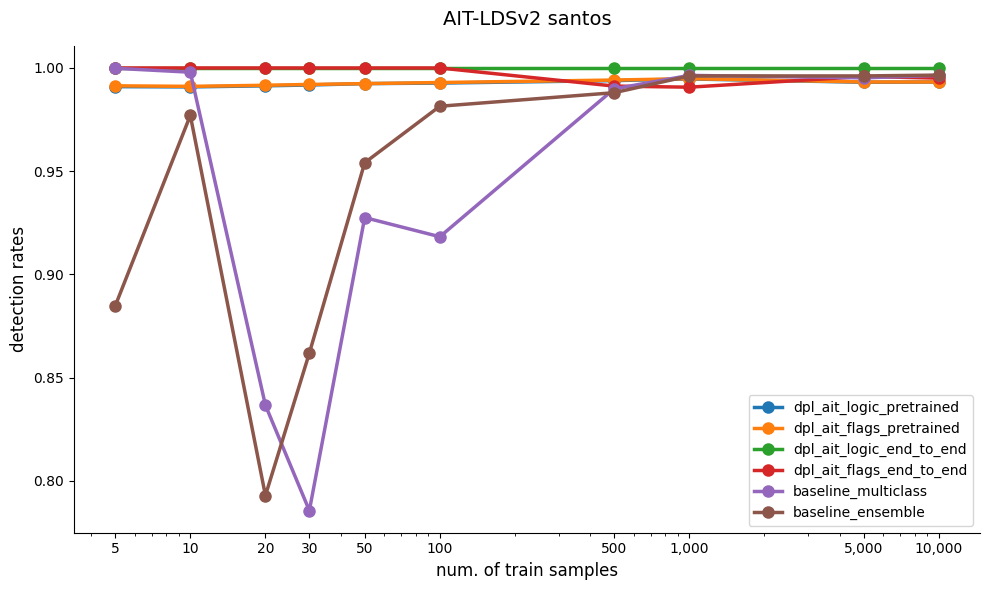

In [80]:
metric = "detection_rates"
num_samples_plot(experiments, metric, plots_dir, plots_title)